In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

In [2]:
# Load dataset (space-separated file)
df = pd.read_csv("german.data", sep=' ', header=None)

print("First 5 rows:")
print(df.head())

First 5 rows:
    0   1    2    3     4    5    6   7    8     9   ...    11  12    13  \
0  A11   6  A34  A43  1169  A65  A75   4  A93  A101  ...  A121  67  A143   
1  A12  48  A32  A43  5951  A61  A73   2  A92  A101  ...  A121  22  A143   
2  A14  12  A34  A46  2096  A61  A74   2  A93  A101  ...  A121  49  A143   
3  A11  42  A32  A42  7882  A61  A74   2  A93  A103  ...  A122  45  A143   
4  A11  24  A33  A40  4870  A61  A73   3  A93  A101  ...  A124  53  A143   

     14 15    16 17    18    19 20  
0  A152  2  A173  1  A192  A201  1  
1  A152  1  A173  1  A191  A201  2  
2  A152  1  A172  2  A191  A201  1  
3  A153  1  A173  2  A191  A201  1  
4  A153  2  A173  2  A191  A201  2  

[5 rows x 21 columns]


In [3]:
# Define column names for the dataset
# These names describe what each column in the dataset represents
columns = [
    'status', 'duration', 'credit_history', 'purpose', 'credit_amount',
    'savings', 'employment', 'installment_rate', 'personal_status',
    'other_debtors', 'residence_since', 'property', 'age',
    'other_installment_plans', 'housing', 'existing_credits',
    'job', 'num_dependents', 'telephone', 'foreign_worker', 'target'
]

# Assign the defined column names to the dataframe
df.columns = columns

print("\nDataset with column names:")
print(df.head())


Dataset with column names:
  status  duration credit_history purpose  credit_amount savings employment  \
0    A11         6            A34     A43           1169     A65        A75   
1    A12        48            A32     A43           5951     A61        A73   
2    A14        12            A34     A46           2096     A61        A74   
3    A11        42            A32     A42           7882     A61        A74   
4    A11        24            A33     A40           4870     A61        A73   

   installment_rate personal_status other_debtors  ...  property age  \
0                 4             A93          A101  ...      A121  67   
1                 2             A92          A101  ...      A121  22   
2                 2             A93          A101  ...      A121  49   
3                 2             A93          A103  ...      A122  45   
4                 3             A93          A101  ...      A124  53   

   other_installment_plans housing existing_credits   job num_de

In [4]:
# Convert target:
# 1 = good → 0 (No Default)
# 2 = bad  → 1 (Default)

df['target'] = df['target'].map({1: 0, 2: 1})

print("\nTarget distribution:")
print(df['target'].value_counts())


Target distribution:
target
0    700
1    300
Name: count, dtype: int64


In [5]:
# Separate the input features (X) and the target variable (y)

# X will contain all columns EXCEPT 'target'
# axis=1 means we are dropping a COLUMN (not a row)
X = df.drop('target', axis=1)

# y will contain ONLY the 'target' column
# This is what we want to predict (e.g., loan approval)
y = df['target']

In [6]:
# Identify categorical and numerical columns from the dataset

# Select columns with data type 'object' → these are categorical (text-based)
# Example: job type, housing, purpose, etc.
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

# Select columns with data type 'int64' → these are numerical (numbers)
# Example: age, credit amount, duration, etc.
numerical_cols = X.select_dtypes(include=['int64']).columns.tolist()

# Print the identified categorical columns
print("\nCategorical columns:", categorical_cols)

# Print the identified numerical columns
print("Numerical columns:", numerical_cols)


Categorical columns: ['status', 'credit_history', 'purpose', 'savings', 'employment', 'personal_status', 'other_debtors', 'property', 'other_installment_plans', 'housing', 'job', 'telephone', 'foreign_worker']
Numerical columns: ['duration', 'credit_amount', 'installment_rate', 'residence_since', 'age', 'existing_credits', 'num_dependents']


In [7]:
# Create a preprocessing pipeline using ColumnTransformer
# This allows us to apply different transformations to different column types
preprocessor = ColumnTransformer(
    transformers=[
        # 'cat' → name of this transformation step (just a label)
        # OneHotEncoder → converts categorical (text) data into numerical format
        # handle_unknown='ignore' → ignores new/unseen categories during prediction
        # categorical_cols → list of categorical columns to apply this on
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        # 'num' → name of this transformation step
        # 'passthrough' → keeps numerical columns unchanged (no transformation)
        # numerical_cols → list of numerical columns
        ('num', 'passthrough', numerical_cols)
    ]
)

In [8]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
# Print the shape (rows, columns) of training data
print("\nTrain size:", X_train.shape)

# Print the shape (rows, columns) of testing data
print("Test size:", X_test.shape)


Train size: (800, 20)
Test size: (200, 20)


In [9]:
# Create a machine learning pipeline
# Pipeline = combines preprocessing + model into one flow
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(
        criterion='entropy',
        max_depth=5,
        random_state=42
    ))
])

In [10]:
# Train the pipeline model using the training data
model.fit(X_train, y_train)

print("\nModel training complete!")


Model training complete!


In [11]:
# Use the trained model to make predictions on the test data
y_pred = model.predict(X_test)

print("\nSample predictions:", y_pred[:10])


Sample predictions: [0 0 1 1 0 0 1 0 1 0]


In [12]:
# Calculate accuracy of the model
# accuracy_score compares actual values (y_test) with predicted values (y_pred)
accuracy = accuracy_score(y_test, y_pred)

# Print the accuracy value
print("\nAccuracy:", accuracy)

# Print detailed performance metrics
print("\nClassification Report:")

# classification_report gives:
# - Precision → how many predicted positives are correct
# - Recall → how many actual positives are correctly identified
# - F1-score → balance between precision and recall
# - Support → number of actual samples per class

# target_names → labels for classes (0 = No Default, 1 = Default)
print(classification_report(y_test, y_pred, target_names=["No Default", "Default"]))


Accuracy: 0.67

Classification Report:
              precision    recall  f1-score   support

  No Default       0.77      0.76      0.76       140
     Default       0.45      0.47      0.46        60

    accuracy                           0.67       200
   macro avg       0.61      0.61      0.61       200
weighted avg       0.67      0.67      0.67       200




Confusion Matrix:
[[106  34]
 [ 32  28]]


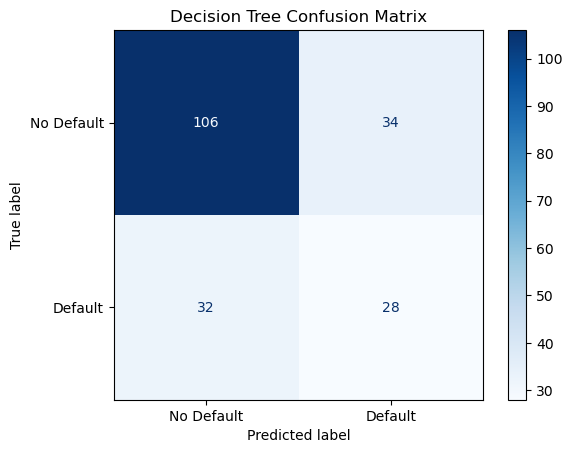

In [13]:
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Default", "Default"])
disp.plot(cmap="Blues")

plt.title("Decision Tree Confusion Matrix")
plt.show()

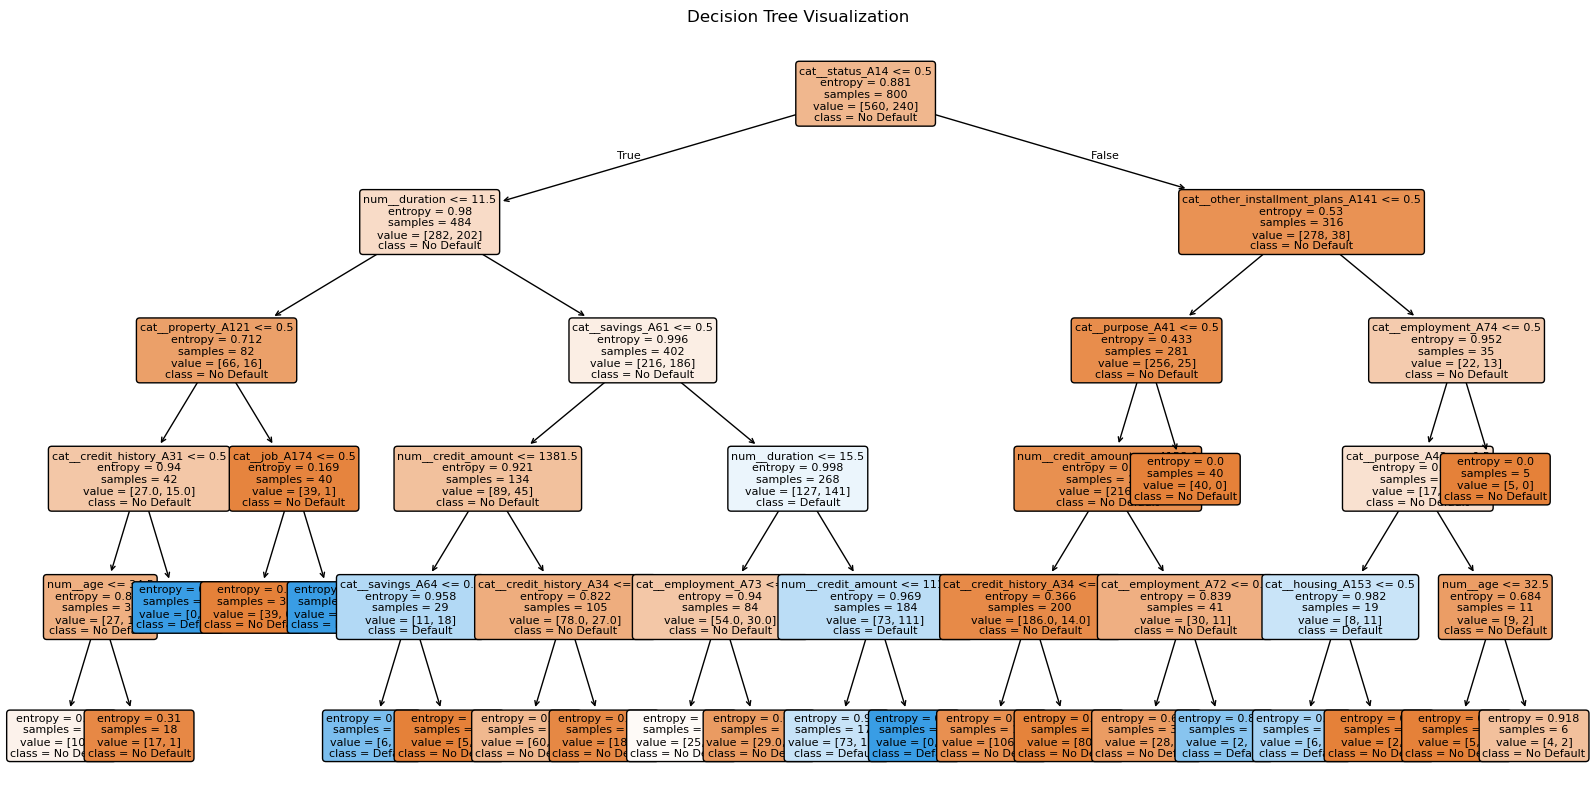

In [14]:
# Extract trained tree
tree_model = model.named_steps['classifier']

# Get feature names after encoding
feature_names = model.named_steps['preprocessor'].get_feature_names_out()

plt.figure(figsize=(20, 10))
plot_tree(
    tree_model,
    feature_names=feature_names,
    class_names=["No Default", "Default"],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title("Decision Tree Visualization")
plt.show()

In [15]:
importances = tree_model.feature_importances_

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print("\nTop 10 Important Features:")
print(importance_df.head(10))


Top 10 Important Features:
                              Feature  Importance
3                     cat__status_A14    0.288977
54                      num__duration    0.118302
55                 num__credit_amount    0.111327
40  cat__other_installment_plans_A141    0.057325
36                 cat__property_A121    0.055640
8             cat__credit_history_A34    0.049728
19                   cat__savings_A61    0.043635
58                           num__age    0.039515
5             cat__credit_history_A31    0.038206
22                   cat__savings_A64    0.037999


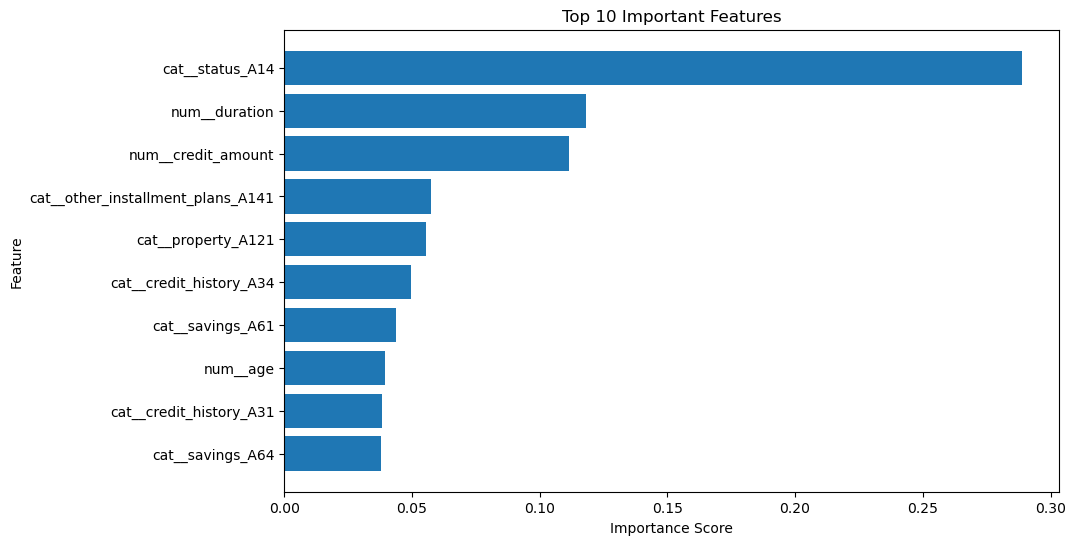

In [16]:
top_features = importance_df.head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_features['Feature'], top_features['Importance'])
plt.gca().invert_yaxis()

plt.title("Top 10 Important Features")
plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.show()